## Predicting Heart Disease using Machine Learning
This notebook will introduce some foundation machine learning and data science concepts by exploring the problem of heart disease classification.

For example, given a person's health characteristics, we're going to build a model to predict whether or not they have heart disease.

It is intended to be an end-to-end example of what a data science and machine learning proof of concept might look like.

What is classification?
Classification involves deciding whether a sample is part of one class or another (binary classification).

If there are multiple class options, it's referred to as multi-class classification.

What we'll end up with
We'll start with the heart disease dataset we've worked on in previous modules and we'll approach the problem following the machine learning modelling framework.


6 Step Machine Learning Modelling Framework
More specifically, we'll look at the following topics.

Step	What we'll cover
Exploratory data analysis (EDA)	The process of going through a dataset and discovering more about it.
Model training	Create model(s) to learn to predict a target variable based on other variables.
Model evaluation	Evaluating a model's predictions using problem-specific evaluation metrics.
Model comparison	Comparing several different models to find the best one.
Model hyperparameter tuning	Once we've found a good model, can we tweak its hyperparameters to improve it?
Feature importance	Since we're predicting the presence of heart disease, are there some features/characteristics that are more important for prediction?
Cross-validation	If we do build a good model, can we be sure it will work on unseen data?
Reporting what we've found	If we had to present our work, what would we show someone?
To work through these topics, we'll use pandas, Matplotlib and NumPy for data anaylsis, as well as, Scikit-Learn for machine learning and modelling tasks.


Tools which can be used for each step of the machine learning modelling process.
We'll work through each step and by the end of the notebook, we'll have a handful of models, all which can predict whether or not a person has heart disease based on a number of different parameters at a considerable accuracy.

You'll also be able to describe which parameters are more indicative than others, for example, sex may be more important than age.

1. Going through the 6 step ML framework
1.1 Problem Definition
In our case, the problem we will be exploring is binary classification (a sample can only be one of two things).

This is because we're going to be using a number of differnet features (pieces of information such as health characteristics) about a person to predict whether they have heart disease or not.

In a statement,

Given clinical parameters about a patient, can we predict whether or not they have heart disease?

1.2 What data are we using?
What you'll want to do here is dive into the data your problem definition is based on.

This may involve, sourcing data (if it doesn't already exist), defining different parameters, talking to experts about it and finding out what you should expect.

The original data came from the Cleveland database from UCI Machine Learning Repository.

Howevever, we've downloaded it in a formatted way from Kaggle.

The original database contains 76 attributes, but here only 14 attributes will be used. Attributes (also called features) are the variables what we'll use to predict our target variable.

Attributes and features are also referred to as independent variables and a target variable can be referred to as a dependent variable.

Note: We use the independent variable(s)to predict our dependent variable(s).

In our case, the independent variables are a patient's different medical attributes and the dependent variable is whether or not they have heart disease.

1.3 How will we evaluate our model?
An evaluation metric is something you usually define at the start of a project.

However, since machine learning is very experimental, it can change over time.

But to begin a project, you might say something like:

If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursure this project.

The reason this is helpful is it provides a rough goal for a machine learning engineer or data scientist to work towards.

Of course, as the project progresses and gets tested in the real world, you may have to adjust this goal/threshold.

1.4 Which features of the data will be important to us?
Features are different parts and characteristics of the data.

During this step, you'll want to start exploring what each portion of the data relates to and then create a reference you can use to look up later on.

One of the most common ways to do this is to create a data dictionary.

Heart Disease Data Dictionary
A data dictionary describes the data you're dealing with.

Not all datasets come with them so this is where you may have to do your research or ask a subject matter expert (someone who knows about the data) for more.

The following are the features we'll use to predict our target variable (heart disease or no heart disease).

Feature	Description	Example Values
age	Age in years	29, 45, 60
sex	1 = male; 0 = female	0, 1
cp	Chest pain type	0: Typical angina (chest pain), 1: Atypical angina (chest pain not related to heart), 2: Non-anginal pain (typically esophageal spasms (non heart related), 3: Asymptomatic (chest pain not showing signs of disease)
trestbps	Resting blood pressure (in mm Hg on admission to the hospital)	120, 140, 150
chol	Serum cholesterol in mg/dl	180, 220, 250
fbs	Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)	0, 1
restecg	Resting electrocardiographic results	0: Nothing to note, 1: ST-T Wave abnormality, 2: Left ventricular hypertrophy
thalach	Maximum heart rate achieved	160, 180, 190
exang	Exercise induced angina (1 = yes; 0 = no)	0, 1
oldpeak	ST depression (heart potentially not getting enough oxygen) induced by exercise relative to rest	0.5, 1.0, 2.0
slope	The slope of the peak exercise ST segment	0: Upsloping, 1: Flatsloping, 2: Downsloping
ca	Number of major vessels (0-3) colored by fluoroscopy	0, 1, 2, 3
thal	Thalium stress result	1: Normal, 3: Normal, 6: Fixed defect, 7: Reversible defect
target	Have disease or not (1 = yes; 0 = no)	0, 1
Note: No personal identifiable information (PPI) can be found in the dataset.

It's a good idea to save these to a Python dictionary or in an external file, so we can look at them later without coming back here.

2. Preparing the tools
At the start of any project, it's custom to see the required libraries imported in a big chunk (as you can see in the code cell below).

However, in practice, when starting on new projects you may import libraries as you go (because you don't know what you need ahead of time).

After you've spent a couple of hours working on your problem, you'll probably want to do some tidying up.

This is where you may want to consolidate every library you've used at the top of your notebook.

The libraries you use will differ from project to project. But there are a few which will you'll likely take advantage of during almost every structured data project.

pandas for data analysis.
NumPy for numerical operations.
Matplotlib/seaborn for plotting or data visualization.
Scikit-Learn for machine learning modelling and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

import datetime
print(f"Notebook last updated: {datetime.datetime.now()}\n")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Notebook last updated: 2025-04-27 18:32:50.993968

pandas version: 2.2.3
matplotlib version: 3.10.1
Scikit-Learn version: 1.6.1


In [2]:
df = pd.read_csv("data/heart-disease.csv")
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.shape

(303, 14)

4. Data Exploration (exploratory data analysis or EDA)
Once you've imported a dataset, the next step is to explore.

Or in formal terms, perform an Exploratory Data Analysis (EDA).

There's no set way of doing this.

But what you should be trying to do is become more and more familiar with the dataset.

Compare different columns to each other, compare them to the target variable.

Refer back to your data dictionary and remind yourself of what different columns mean.

One of my favourites is viewing 10-100 random samples of the data.

Our goal here is to become a subject matter expert on the dataset you're working with.

So if someone asks you a question about it, you can give them an explanation and when you start building models, you can sound check them to make sure they're not performing too well (overfitting and memorizing the data rather than learning generalizable patterns) or why they might be performing poorly (underfitting or not learning patterns in the data).

Since EDA has no real set methodolgy, the following is a short check list you might want to walk through:

What question(s) are you trying to solve (or prove wrong)?
What kind of data do you have and how do you treat different types?
What’s missing from the data and how do you deal with it?
Where are the outliers and why should you care about them?
How can you add, change or remove features to get more out of your data?
Once of the quickest and easiest ways to check your data is with the head() function.

Calling it on any dataframe will print the top 5 rows, tail() calls the bottom 5. You can also pass a number to them like head(10) to show the top 10 rows.

In [4]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [5]:
df.target.value_counts(normalize=True)

target
1    0.544554
0    0.455446
Name: proportion, dtype: float64

<Axes: xlabel='target'>

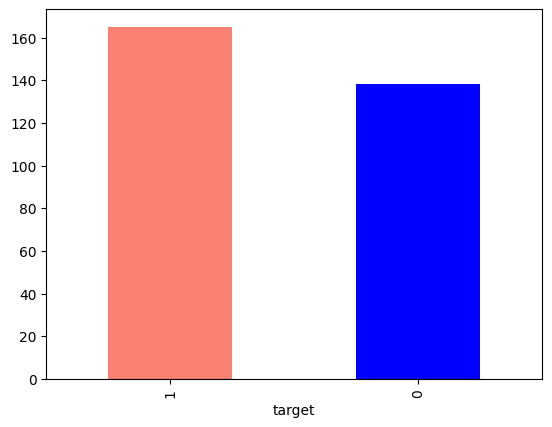

In [6]:
df.target.value_counts().plot(kind="bar", color=["salmon","blue"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [10]:
pd.crosstab(index=df.target, columns=df.sex)


sex,0,1
target,,
0,24,114
1,72,93


### What can we infer from this? Let's make a simple heuristic.

Since there are about 100 women and 72 of them have a positive value of heart disease being present, we might infer, based on this one variable if the participant is a woman, there's a ~72% (72/96 women in our dataset are positive for heart disease) chance she has heart disease.

As for males, there's about 200 total with around half (93/207) indicating a presence of heart disease.

So we might predict, if the participant is male, 50% of the time he will have heart disease.

Averaging these two values, we can assume, based on no other parameters, if there's a person, there's a 62.5% chance they have heart disease.

This can be our very simple baseline, we'll try to beat it with machine learning.

Note: A baseline is a simple model or estimate you start with and try to beat/confirm throughout your experiments. It can be as simple as looking at the data as we've done and creating a predictive heuristic to move forward.

### Making our comparison visual
I'm going to introduce you to a motto I remind myself of whenever I'm exploring data.

Visualize, visualize, visualize! - The data explorer's motto.

This is because it's very helpful whenever you're dealing with a new dataset to visualize as much as you can to build up an idea of the dataset in your head.

And one of the best ways to create visualizations is to make plots (graphical representations of our data).

We can plot our pd.crosstab comparison by calling the plot() method and passing it a few parameters:

kind- The type of plot you want (e.g. "bar" for a bar plot).
figsize=(length, width) - How big you want it to be.
color=[colour_1, colour_2] - The different colours you'd like to use.
Different metrics are represented best with different kinds of plots.

In our case, a bar graph is great. We'll see examples of more later. And with a bit of practice, you'll gain an intuition of which plot to use with different variables.

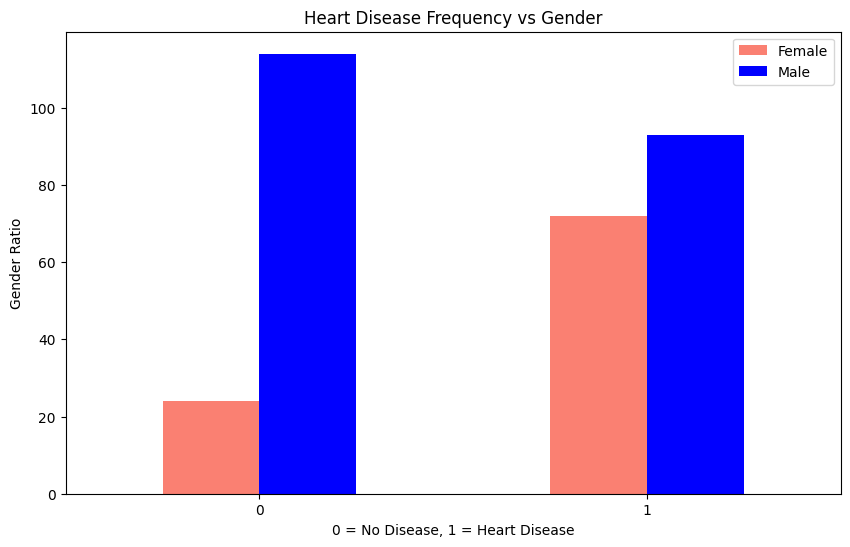

In [12]:
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10,6),
                                    color=["salmon", "blue"])
# some attributes
plt.title("Heart Disease Frequency vs Gender")
plt.xlabel("0 = No Disease, 1 = Heart Disease")
plt.ylabel("Gender Ratio")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0);

### Comparing age and maximum heart rate
Let's try combining a couple of independent variables, such as, age and thalach (maximum heart rate) and then comparing them to our target variable heart disease.

Because there are so many different values for age and thalach, we'll use a scatter plot

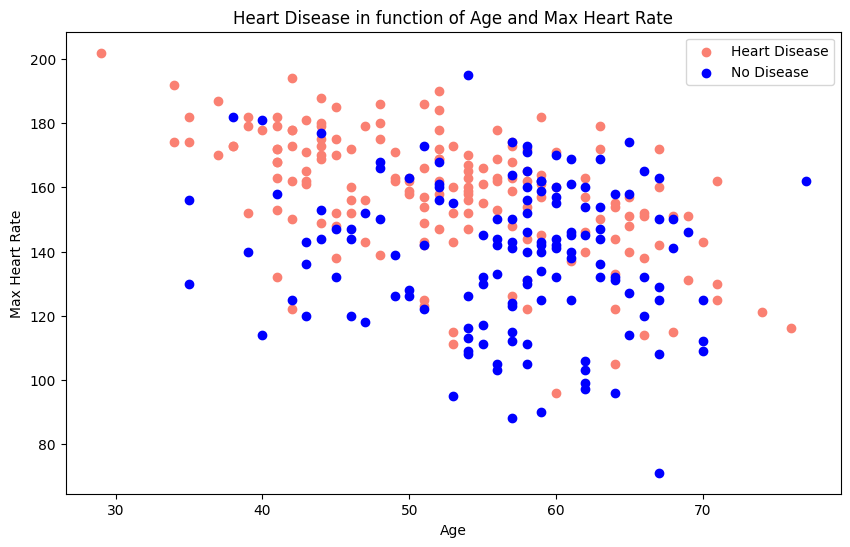

In [13]:
plt.figure(figsize=(10,6))

# Start with positve examples
plt.scatter(df.age[df.target == 1],
            df.thalach[df.target == 1],
            c="salmon")

# Now for negative examples, we want them on the same plot, so we call plt again
plt.scatter(df.age[df.target == 0],
            df.thalach[df.target == 0],
            c="blue")

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.legend(["Heart Disease", "No Disease"])
plt.ylabel("Max Heart Rate");


### What can we infer from this?

It seems the younger someone is, the higher their max heart rate (dots are higher on the left of the graph) and it seems there may be more heart disease in the younger population too (more salmon color dots).

Both of these are observational of course, but this is what we're trying to do, build an understanding of the data.

Let's check the age distribution.

Note: Distribution can considered as the spread of data. As in, when viewed as a whole, what different values appear in the data?

<Axes: ylabel='Frequency'>

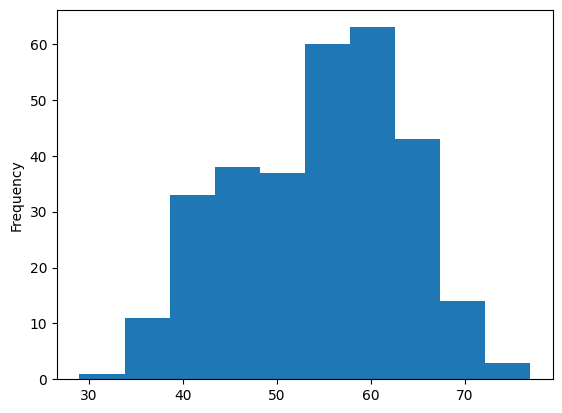

In [14]:
df.age.plot.hist()

### Comparing heart disease frequency and chest pain type
Let's try comparing another independent variable with our target variable.

This time, we'll use cp (chest pain) as the independent variable.

We'll use the same process as we did before with sex.

cp:	Chest pain type -	
        0: Typical angina (chest pain), 
        1: Atypical angina (chest pain not related to heart), 
        2: Non-anginal pain (typically esophageal spasms (non heart related), 
        3: Asymptomatic (chest pain not showing signs of disease)

In [16]:
pd.crosstab(index=df.cp, columns=df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


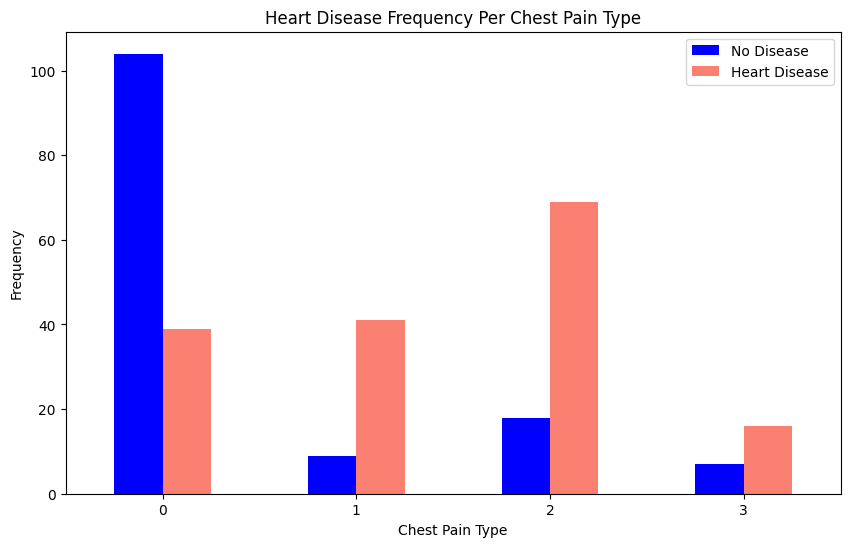

In [18]:
# Create a new crosstab and base plot
pd.crosstab(df.cp,df.target).plot(kind="bar",
                                  figsize=(10,6),
                                  color=["blue", "salmon"])

# Add attributes to the plot to make it more readable
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Heart Disease"])
plt.xticks(rotation = 0);

### Correlation between independent variables
Finally, we'll compare all of the independent variables in one hit.

Why?

Because this may give an idea of which independent variables may or may not have an impact on our target variable.

We can do this using pd.DataFrame.corr() which will create a correlation matrix for us, in other words, a big table of numbers telling us how related each variable is the other.

<Axes: >

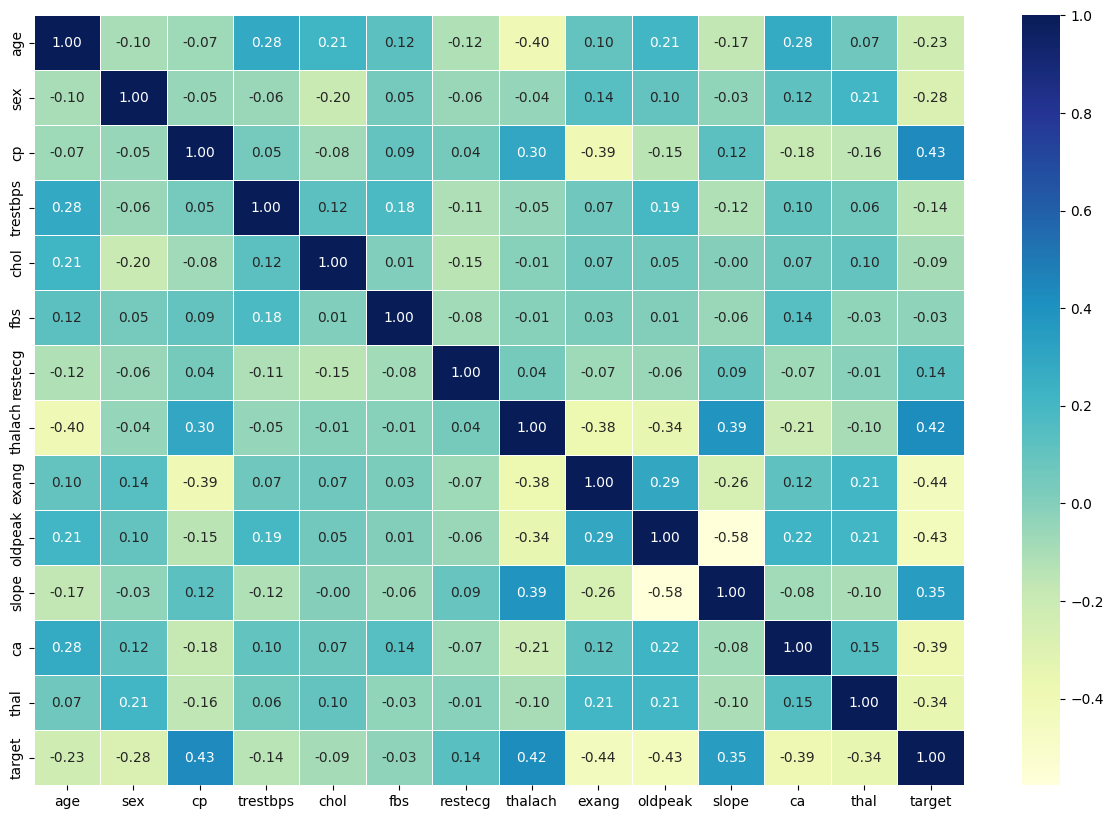

In [20]:
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
            annot=True,
            linewidths=0.5,
            fmt=".2f",
            cmap="YlGnBu")
# corr_matrix

Much better. A higher positive value means a potential positive correlation (increase) and a higher negative value means a potential negative correlation (decrease).

## Model

Remember, we do exploratory data analysis (EDA) to start building an intuition of the dataset.

What have we learned so far?

Aside from our baseline estimate using sex, the rest of the data seems to require a bit more exploration before we draw any conclusions.

So what we'll do next is model driven EDA, meaning, we'll use machine learning models to drive our next questions.

A few extra things to remember:

Not every EDA will look the same, what we've seen here is an example of what you could do for structured, tabular dataset.
You don't necessarily have to do the same plots as we've done here, there are many more ways to visualize data, I encourage you to look at more.
Quite often, we'll want to find:

Distributions - What's the spread of the data? We can do this with pd.DataFrame.hist(column="target_column").

Missing values - Is our data missing anything? Why might this be the case and will this affect us going forward? We can do this with pd.DataFrame.info() or pd.isnull().

Outliers - Are there any samples that lay quite far outside the rest of our data's distributions? How might these affect the data going forward?

We've explored the data, now we'll try to build a machine learning model to be able to predict our target variable based on the 13 independent variables.

Remember our problem?

Given clinical parameters about a patient, can we predict whether or not they have heart disease?

That's what we'll be trying to answer.

And remember our evaluation metric?

If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursure this project.

That's what we'll be aiming for.

But before we build a model, we have to get our dataset ready.

Let's look at it again.

In [21]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


We're trying to predict our target variable using all of the other variables.

To do this, we'll split the target variable from the rest.

We can do this by creating:

X - Our features (all variables except the target column) using pd.DataFrame.drop(labels="target").
y - Our target variable using df.target.to_numpy() (this will extract the target column as a NumPy array).

In [22]:
X = df.drop(labels="target", axis=1)
y = df.target.to_numpy()

In [23]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [24]:
y, type(y)

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### 5.1 Creating a training and test split
Now comes one of the most important concepts in machine learning, creating a training/test split.

This is where we'll split our data into a training set and a test set.

We'll use our training set to train our model and our test set to evaluate it.

All the samples in the training set must be separate from those in the test set (and vice versa).

In short:

Training set (often 70-80% of total data) - Model learns patterns on this dataset to hopefully be able to predict on similar but unseen samples.
Testing set (often 20-30% of total data) - Trained model gets evaluated on these unseen samples to see how the patterns learned from the training set may perform on future unseen samples (e.g. when used in an application or production setting). However, performance on the test set is not guaranteed in the real world.

### Why not use all the data to train a model?
Let's say you wanted to take your model into the hospital and start using it on patients.

How would you know how well your model goes on a new patient not included in the original full dataset you had?

This is where the test set comes in.

It's used to mimic taking your model to a real environment as much as possible.

And it's why it's important to never let your model learn from the test set, it should only be evaluated on it.

To split our data into a training and test set, we can use Scikit-Learn's sklearn.model_selection.train_test_split() and feed it our independent and dependent variables (X & y).

In [25]:
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

The test_size parameter is used to tell the train_test_split() function how much of our data we want in the test set.

A rule of thumb is to use 80% of your data to train on and the other 20% to test on.

For our problem, a train and test set are enough. But for other problems, you could also use a validation (train/validation/test) set or cross-validation (we'll see this later on).

But again, each problem will differ.

To learn more about the importance of validation and test sets, I'd recommend reading:

How (and why) to create a good validation set by Rachel Thomas.
The importance of a test set by Daniel Bourke.
Let's look at our training data.

In [26]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3


In [27]:
y_train, len(y_train)

(array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
        1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1],
       dtype=int64),
 242)

Beautiful, we can see we're using 242 samples to train on.

Let's look at our test data.


In [28]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [29]:
y_test, len(y_test)

(array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64),
 61)

### 5.2 Choosing a model
Now we've got our data prepared, we can start to fit models.

In the modern world of machine learning, there are many potential models we can choose from.

Rather than trying every potential model, it's often good practice to try a handful and see how they go.

We'll start by trying the following models and comparing their results.

Logistic Regression - sklearn.linear_model.LogisticRegression()
K-Nearest Neighbors - sklearn.neighbors.KNeighboursClassifier()
RandomForest - sklearn.ensemble.RandomForestClassifier()
Why these?
If we look at the Scikit-Learn algorithm machine learning model map, we can see we're working on a classification problem and these are the algorithms it suggests (plus a few more).

Good questions.

I was confused too when I didn't see Logistic Regression listed as well because when you read the Scikit-Learn documentation on it, you can see it's a model for classification.

And as for sklearn.svm.LinearSVC, let's pretend we've tried it (you can try it for yourself if you like), and it doesn't work, so we're following other options in the map.

For now, knowing each of these algorithms inside and out is not essential (however, this would be a fantastic extension to this project).

Machine learning and data science is an iterative practice.

These algorithms are tools in your toolbox.

In the beginning, on your way to becoming a practitioner, it's more important to understand your problem (such as, classification versus regression) and what tools you can use to solve it.

Since our dataset is relatively small, we can run some quick experiments to see which algorithm performs best and iteratively try to improve it.

Many of the algorithms in the Scikit-Learn library have similar APIs (Application Programming Interfaces).

For example, for training a model you can use model.fit(X_train, y_train).

And for scoring a model model.score(X_test, y_test) (scoring a model compares predictions to the ground truth labels).

For classification models, calling score() usually defaults to returning the ratio (accuracy) of correct predictions (1.0 = 100% correct).

Since the algorithms we've chosen implement the same methods for fitting them to the data as well as evaluating them, let's put them in a dictionary and create a which fits and scores them.

In [30]:
models = {
    "KNN":KNeighborsClassifier(),
    "Logistic Regression":LogisticRegression(max_iter=100),
    "Random Forest":RandomForestClassifier()
}

def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data
    X_test : testing data
    y_train : labels assosciated with training data
    y_test : labels assosciated with test data
    """
    np.random.seed(42)
    model_scores = {}
    for name, model in models.items():
        model.fit(X_train,y_train)
        model_scores[name] = model.score(X_test, y_test)
    return model_scores    

In [31]:
model_scores = fit_and_score(
    models= models,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test

)

model_scores

c:\Users\HP\coding-projects\AI-Agents\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6885245901639344,
 'Logistic Regression': 0.8852459016393442,
 'Random Forest': 0.8360655737704918}

### 5.3 Comparing the results of several models
Since we've saved our models scores to a dictionary, we can plot them by first converting them to a DataFrame.

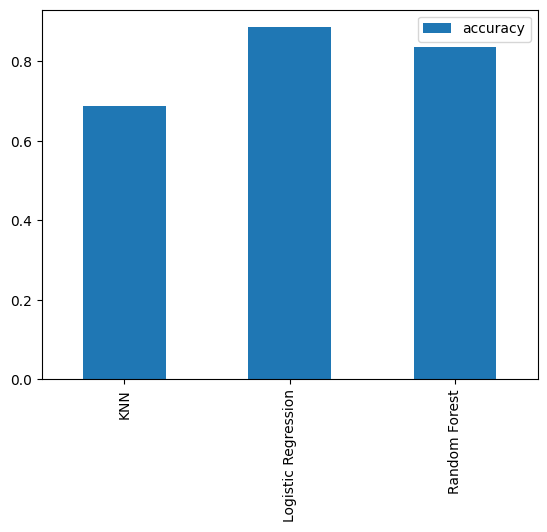

In [34]:
model_compare = pd.DataFrame(model_scores,index=['accuracy'])
model_compare.T.plot.bar();

From the plot it looks like the sklearn.linear_model.LogisticRegression() model performs best.

Now... since we've found the best model.

### Term	Definition
**Hyperparameter tuning**:	Many machine learning models have a series of settings/dials you can turn to dictate how they perform. Changing these values may increase or decrease model performance. The practice of figuring out the best settings for a model is called hyperparameter tuning.
**Feature importance**:	If there are a large amount of features we're using to make predictions, do some have more importance than others? For example, for predicting heart disease, which is more important, sex or age?

**Confusion matrix**:	Compares the predicted values with the true values in a tabular way, if 100% correct, all values in the matrix will be top left to bottom right (diagnol line).

**Cross-validation**:	Splits your dataset into multiple versions of training and test sets and trains/evaluations your model on each different version. This ensures that your evaluation metrics are across several different splits of data rather than a single split (if it was only a single split, you might get lucky and get better than usual results, the same for the reverse, if you get a poor split, you might find your metrics lower than they should be).

**Precision**:	A common classification evaluation metric. Measures the proportion of true positives over total number of samples. Higher precision leads to fewer false positives.

**Recall**: | A common classification evaluation metric. Measures the proportion of true positives over total number of true positives and false negatives. Higher recall leads to fewer false negatives.

**F1 score**: Combines precision and recall into one metric. 1 is best, 0 is worst. 

**Classification report**: Sklearn has a built-in function called classification_report() which returns some of the main classification metrics such as precision, recall and f1-score. 

**ROC Curve**: Receiver Operating Characterisitc is a plot of true positive rate versus false positive rate. A perfect curve will follow the left and top border of a plot. 

**Area Under Curve (AUC)**:  The area underneath the ROC curve. A perfect model achieves a score of 1.0.

Woah!

There are a fair few things going on here but nothing we can't handle.

We'll explore each of these further throughout the rest of the notebook.

In the meantime, feel free to read more at the linked resources.

### 6. Hyperparameter tuning and cross-validation
To cook your favourite dish, you know to set the oven to 180 degrees and turn the grill on.

But when your roommate cooks their favourite dish, they use 200 degrees and the fan-forced mode.

Same oven, different settings, different outcomes.

The same can be done for machine learning algorithms. You can use the same algorithms but change the settings (hyperparameters) and get different results.

But just like turning the oven up too high can burn your food, the same can happen for machine learning algorithms.

You change the settings and it works so well, it overfits (does too well) the data.

We're looking for the Goldilocks model.

One which does well on our training dataset but also on unseen examples like in the testing dataset/real world.

To test different hyperparameters, you could use a validation set but since we don't have much data, we'll use cross-validation.

Note: A validation set is a third player in the training/test split game. It's designed to be used in between a training and test set. You can think of it as the practice exam before the final exam. As in, the training set is the course material to learn on, the validation set is the practice exam to practice and tweak your skills on and the test set is the final exam to push your skills. In machine learning, the model learns patterns on the training set and then you can tweak hyperparameters to improve results on the validation set before finally testing your model on the testing set. All samples in the training, validation and test sets should be kept exclusive of each other.

The most common type of cross-validation is k-fold.

It involves splitting your data into k-fold's or k-different splits of the data and then training and testing a model on each split.

For example, let's say we had 5 folds (k = 5).

This is what it might look like.


Normal train and test split versus 5-fold cross-validation
You have 5 different versions of train and test splits.

This means you'll be able to train and test 5 different versions of your model on different data splits and calculate the average performance.

Why do this?

This prevents us from focusing too much on the metrics from one data split (imagine the data split we do contains all the easy samples and the performance metrics we use say that the model performs better than it does).

We'll be using this setup to tune the hyperparameters of some of our models and then evaluate them.

We'll also get a few more metrics like precision, recall, F1-score and ROC at the same time.

Here's the plan:

###**Tune model hyperparameters**, and see which performs best
Perform cross-validation
Plot ROC curves
Make a confusion matrix
Get precision, recall and F1-score metrics
Find the most important model features
6.1 Tune KNeighborsClassifier (K-Nearest Neighbors or KNN) by hand
There are several hyperparameters we can tune for the K-Nearest Neighbors (KNN) algorithm (or sklearn.neighbors.KNeighborsClassifier).

But for now, let's start with one, the number of neighbors.

The default is 5 (n_neigbors=5).

What are neighbours?

Well, imagine all our different samples on one graph like the scatter graph several cells above.

KNN works by assuming dots which are closer together belong to the same class.

If n_neighbors=5 then it assume a dot with the 5 closest dots around it are in the same class.

We've left out some details here like what defines close or how distance is calculated but I encourage you to research them by going through the documentation.

For now, let's try a few different values of n_neighbors and test how the results go.